In [96]:
import sectio
Section_n = sectio.db.get_section('sections_rhs', "RHS80x40x4", subdivision='calc')
# Section_n = sectio.db.get_section('sections_heaa', "HE100AA", subdivision=256)
Section_n

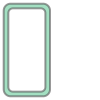

In [97]:
Section_n.polygon

In [98]:
Section_n.mesh_section

<bound method CrossSection.mesh_section of <sectio.core.CrossSection object at 0x71880ffb4d10>>

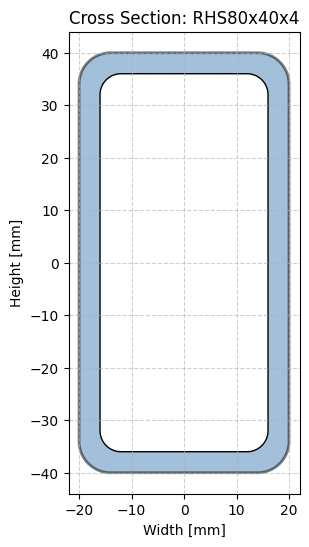

In [99]:
import matplotlib.pyplot as plt

def plot_section(cs):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot the exterior
    x, y = cs.polygon.exterior.xy
    ax.fill(x, y, alpha=0.5, fc='steelblue', ec='black', lw=2)
    
    # Plot any holes (if present)
    for interior in cs.polygon.interiors:
        xi, yi = interior.xy
        ax.fill(xi, yi, fc='white', ec='black', lw=1)
        
    ax.set_aspect('equal')
    ax.set_title(f"Cross Section: {cs.metadata.get('Section_ID', 'Unknown')}")
    ax.set_xlabel("Width [mm]")
    ax.set_ylabel("Height [mm]")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_section(Section_n)

In [100]:
mesh = Section_n.mesh_section(max_area=0.5)

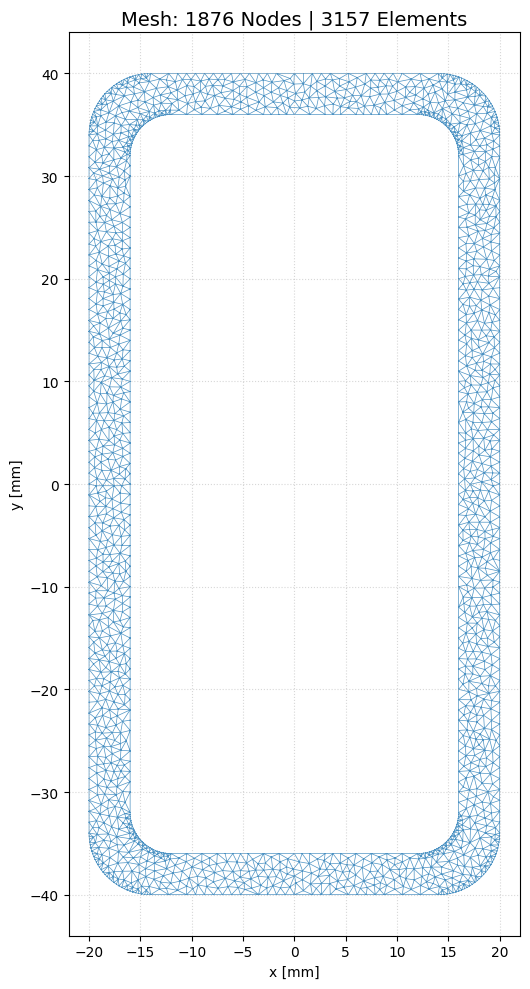

In [101]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

# 1. Access the mesh from your object
# Assuming 'cs' is your CrossSection instance
pts = np.array(mesh.points)
tris = np.array(mesh.elements)

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

# 3. Plot the Triangulation
# If T6, we only use tris[:, :3] for plotting lines
ax.triplot(pts[:, 0], pts[:, 1], tris[:, :3], color='tab:blue', lw=0.5, alpha=0.8)

# # 4. Plot the "Physical" Geometry for comparison
# # This helps see if the mesh discretization is rounding off your corners
# x_ext, y_ext = Section_n.polygon.exterior.xy
# ax.plot(x_ext, y_ext, color='black', lw=2, label="Exterior Boundary")

# for interior in Section_n.polygon.interiors:
#     x_int, y_int = interior.xy
#     ax.plot(x_int, y_int, color='red', lw=1.5, ls='--', label="Hole Boundary")

# 5. Formatting
ax.set_title(f"Mesh: {len(pts)} Nodes | {len(tris)} Elements", fontsize=14)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.grid(True, which='both', linestyle=':', alpha=0.5)
# ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

(682007.155003419, 222391.38865983358)

In [110]:
import numpy as np
from scipy.sparse import coo_matrix, bmat
from scipy.sparse.linalg import spsolve

def solve_j_pro(mesh, iy, iz):
    pts = np.array(mesh.points)
    tris = np.array(mesh.elements)
    facets = np.array(mesh.facets)
    n_nodes = len(pts)
    
    # 1. Build Laplacian Stiffness (K)
    K_data, K_rows, K_cols = [], [], []
    for tri in tris:
        coord = pts[tri]
        x, y = coord[:, 0], coord[:, 1]
        area = 0.5 * abs(x[0]*(y[1]-y[2]) + x[1]*(y[2]-y[0]) + x[2]*(y[0]-y[1]))
        b = np.array([y[1]-y[2], y[2]-y[0], y[0]-y[1]])
        c = np.array([x[2]-x[1], x[0]-x[2], x[1]-x[0]])
        ke = (np.outer(b, b) + np.outer(c, c)) / (4.0 * area)
        for i in range(3):
            for j in range(3):
                K_rows.append(tri[i]); K_cols.append(tri[j]); K_data.append(ke[i,j])
    K = coo_matrix((K_data, (K_rows, K_cols)), shape=(n_nodes, n_nodes)).tocsr()

    # 2. Build the Warping Load Vector (f)
    # This comes from the boundary: Integral of (y*nx - x*ny)
    f = np.zeros(n_nodes)
    for facet in facets:
        n1, n2 = facet
        p1, p2 = pts[n1], pts[n2]
        L = np.linalg.norm(p1 - p2)
        nx = (p2[1] - p1[1]) / L
        ny = -(p2[0] - p1[0]) / L
        # Boundary value at midpoint
        mx, my = (p1[0] + p2[0])/2, (p1[1] + p2[1])/2
        val = (my * nx - mx * ny) * (L / 2)
        f[n1] += val
        f[n2] += val

    # 3. The "Anchor" (Lagrange Multiplier)
    # We add a constraint that sum(omega) = 0 so the matrix isn't singular
    C = np.ones((1, n_nodes))
    A_ext = bmat([[K, C.T], [C, None]], format='csr')
    rhs_ext = np.append(f, 0)
    
    # Solve
    sol = spsolve(A_ext, rhs_ext)
    omega = sol[:-1]

    # 4. Final J = Ip - Warping Loss
    warping_loss = 0
    for tri in tris:
        coord = pts[tri]
        area = 0.5 * abs(coord[0,0]*(coord[1,1]-coord[2,1]) + coord[1,0]*(coord[2,1]-coord[0,1]) + coord[2,0]*(coord[0,1]-coord[1,1]))
        b = np.array([coord[1,1]-coord[2,1], coord[2,1]-coord[0,1], coord[0,1]-coord[1,1]])
        c = np.array([coord[2,0]-coord[1,0], coord[0,0]-coord[2,0], coord[1,0]-coord[0,0]])
        
        # Gradient of omega within triangle
        dw_dx = np.dot(omega[tri], b) / (2.0 * area)
        dw_dy = np.dot(omega[tri], c) / (2.0 * area)
        warping_loss += (dw_dx**2 + dw_dy**2) * area

    j_pro = (iy + iz) - warping_loss
    return j_pro

In [113]:
iy_val = Section_n.Iy
iz_val = Section_n.Iz

In [115]:
# 1. Get the properties for the current section
iy_val, iz_val = calculate_mesh_inertia(mesh) # The triangle-sum method we used earlier

# 2. Solve for J using the Warping Function logic
j_final = solve_j_pro(mesh, iy_val, iz_val)

print(f"--- Professional Torsion Analysis ---")
print(f"Inertia Iy: {iy_val:,.2f} mm⁴")
print(f"Inertia Iz: {iz_val:,.2f} mm⁴")
print(f"Polar Inertia (Ip): {iy_val + iz_val:,.2f} mm⁴")
print(f"Final J (Ip - Loss): {j_final:,.2f} mm⁴")

--- Professional Torsion Analysis ---
Inertia Iy: 682,007.16 mm⁴
Inertia Iz: 222,391.39 mm⁴
Polar Inertia (Ip): 904,398.54 mm⁴
Final J (Ip - Loss): 324,775.81 mm⁴


In [117]:
def plot_warping_stiffness(mesh, omega):
    import matplotlib.pyplot as plt
    pts = np.array(mesh.points)
    tris = np.array(mesh.elements)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    # Plotting the warping function distribution
    tc = ax.tripcolor(pts[:, 0], pts[:, 1], tris, facecolors=None, 
                      C=omega, cmap='coolwarm', shading='gouraud')
    fig.colorbar(tc, label='Warping Function (ω)')
    ax.set_aspect('equal')
    ax.set_title("Warping Function Distribution\n(Red/Blue show sections 'pushing' out of plane)")
    plt.show()

# If you returned 'omega' from your solve_j_pro function:
plot_warping_stiffness(mesh, omega_values)

NameError: name 'omega_values' is not defined